In [1]:
# Dependencies
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Data loading
file_path = '../Dataset/day_approach_maskedID_timeseries.csv'
df = pd.read_csv(file_path)

In [3]:
# Split of datasets
injury_df = df[df['injury']==1]
healthy_df = df[df['injury']==0]

# Injury data points are clearly unbalanced
print(f'Injury data points: {injury_df.shape[0]}')
print(f'Healthy data points: {healthy_df.shape[0]}')
print(f'Proportion of injury data points among the data set: {injury_df.shape[0] / (injury_df.shape[0] + healthy_df.shape[0])}')

Injury data points: 583
Healthy data points: 42183
Proportion of injury data points among the data set: 0.013632324743955478


In [4]:
# Count of data points, injury points and injury proportion per athlete 
athlete_analysis = (
    df.groupby("Athlete ID", as_index=False)
      .agg(
          data_points=("injury", "size"),      # rows per athlete
          injury_events=("injury", "sum")      # number of injury=1 rows
      )
)

athlete_analysis["injury_proportion"] = (
    athlete_analysis["injury_events"] / athlete_analysis["data_points"]
)

athlete_analysis


,Athlete ID,data_points,injury_events,injury_proportion
0,0,310,7,0.022581
1,1,461,2,0.004338
2,2,1291,4,0.003098
3,3,344,3,0.008721
4,4,681,7,0.010279
...,...,...,...,...
69,69,314,5,0.015924
70,70,327,5,0.015291
71,71,392,5,0.012755
72,72,216,0,0.000000


In [5]:
# Summary stats for data point counts
count_stats = athlete_analysis["data_points"].agg(["max", "min", "mean", "std"])

# Summary stats for injury event counts
injury_event_stats = athlete_analysis["injury_events"].agg(["max", "min", "mean", "std"])

# Summary stats for injury proportion
injury_prop_stats = athlete_analysis["injury_proportion"].agg(["max", "min", "mean", "std"])

print("Data points per athlete stats:")
print(count_stats)

print("\nInjury events per athlete stats:")
print(injury_event_stats)

print("\nInjury proportion per athlete stats:")
print(injury_prop_stats)

# We can say that each athlete has around 600 recorded training whereby 7 lead to injury

Data points per athlete stats:
max     1791.000000
min       43.000000
mean     577.918919
std      425.929274
Name: data_points, dtype: float64

Injury events per athlete stats:
max     35.000000
min      0.000000
mean     7.878378
std      8.261070
Name: injury_events, dtype: float64

Injury proportion per athlete stats:
max     0.045205
min     0.000000
mean    0.012959
std     0.011092
Name: injury_proportion, dtype: float64


In [6]:
# Table representing in descending injury proportion of athletes
print("\nAthlete-level analysis:")
print(
    athlete_analysis.sort_values(
        by=["injury_proportion", "injury_events", "data_points"],
        ascending=[False, False, False]
    ).to_string(index=False)
)


Athlete-level analysis:
 Athlete ID  data_points  injury_events  injury_proportion
         29          730             33           0.045205
         42          744             32           0.043011
         26          884             35           0.039593
         36          638             22           0.034483
         68          235              8           0.034043
         56          510             17           0.033333
         65          323             10           0.030960
         53          197              6           0.030457
         35          254              7           0.027559
          8          268              7           0.026119
         10          387             10           0.025840
         64          352              8           0.022727
          0          310              7           0.022581
         58          623             14           0.022472
         38          843             18           0.021352
         57          666       

In [7]:
injury_df.head(30)

,nr. sessions,total km,km Z3-4,km Z5-T1-T2,km sprinting,strength training,hours alternative,perceived exertion,perceived trainingSuccess,perceived recovery,...,km Z5-T1-T2.6,km sprinting.6,strength training.6,hours alternative.6,perceived exertion.6,perceived trainingSuccess.6,perceived recovery.6,Athlete ID,injury,Date
42183,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.08,0.00,0.18,...,0.0,0.0,0.0,0.00,0.08,0.00,0.17,0,1,324
42184,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.01,-0.01,-0.01,...,0.0,0.0,0.0,1.00,0.08,0.00,0.17,0,1,353
42185,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.01,-0.01,-0.01,...,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,0,1,386
42186,1.0,7.5,4.0,0.0,0.0,0.0,0.0,0.10,0.00,0.18,...,0.0,0.0,0.0,1.50,0.08,0.00,0.17,0,1,413
42187,1.0,3.5,0.0,0.0,0.5,0.0,0.0,0.08,0.00,0.18,...,0.9,0.0,0.0,0.00,0.10,0.00,0.18,0,1,461
42188,1.0,6.9,3.9,0.0,0.0,0.0,0.0,0.09,0.00,0.17,...,0.0,0.0,0.0,1.00,0.08,0.00,0.17,0,1,490
42189,1.0,4.9,0.0,0.4,0.0,0.0,0.0,0.09,0.00,0.18,...,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,0,1,528
42190,1.0,16.0,0.0,0.0,0.0,0.0,0.0,0.07,0.14,0.31,...,0.0,0.0,0.0,0.00,0.17,0.65,0.32,1,1,672
42191,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.10,0.87,0.18,...,10.0,0.0,0.0,0.00,0.59,0.53,0.35,1,1,765
42192,2.0,24.0,0.0,6.0,0.0,0.0,0.0,0.77,0.78,0.16,...,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,2,1,680


In [8]:
# Create processing dataframe
processed_df = df.copy()

# Sort chronologically inside each athlete
processed_df = (
    processed_df
    .sort_values(["Athlete ID", "Date"])
    .reset_index(drop=True)
)

# Time gap feature days between consecutive records of same athlete
processed_df["transition_period_days"] = (
    processed_df
    .groupby("Athlete ID")["Date"]
    .diff()
    .fillna(0)
    .astype(int)
)

# Transition feature from previous injury state to current injury state
prev_injury = (
    processed_df
    .groupby("Athlete ID")["injury"]
    .shift(1)
    .fillna(0)
    .astype(int)
)
curr_injury = processed_df["injury"].astype(int)

processed_df["transition"] = prev_injury.astype(str) + "->" + curr_injury.astype(str)

# Numeric encoding for model use
transition_map = {"0->0": 0, "0->1": 1, "1->0": 2, "1->1": 3}
processed_df["transition_code"] = processed_df["transition"].map(transition_map).astype("Int64")

# Cumulated injury per athlete (running total)
processed_df["cumulated_injury"] = (
    processed_df
    .groupby("Athlete ID")["injury"]
    .cumsum()
    .astype(int)
)

# Quick check
processed_df[
    ["Athlete ID", "injury", "transition_period_days", "transition", "cumulated_injury"]
].head(30)

,Athlete ID,injury,transition_period_days,transition,cumulated_injury
0,0,0,0,0->0,0
1,0,0,1,0->0,0
2,0,0,1,0->0,0
3,0,0,1,0->0,0
4,0,0,1,0->0,0
5,0,0,1,0->0,0
6,0,0,1,0->0,0
7,0,0,1,0->0,0
8,0,0,1,0->0,0
9,0,0,1,0->0,0


In [9]:
# Counts and proportion of transitions
transition_counts = processed_df["transition"].value_counts().sort_index()
transition_props = processed_df["transition"].value_counts(normalize=True).sort_index()

# Statistical summary (0->0 dominates heavily)
transition_stats = pd.DataFrame({
    "count": transition_counts,
    "proportion": transition_props
})

print("Transition type stats:")
print(transition_stats)

Transition type stats:
            count  proportion
transition                   
0->0        41818    0.977833
0->1          393    0.009190
1->0          365    0.008535
1->1          190    0.004443


In [10]:
# Stastiscal summary of transition period days
tp = processed_df["transition_period_days"]

print("\nTransition period days - overall descriptive stats:")
print(tp.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

print("\nExtra checks:")
print("Mean:", tp.mean())
print("Std :", tp.std())
print("Min :", tp.min())
print("Max :", tp.max())
print("Rows with gap > 1 day:", (tp > 1).sum())
print("Rows with gap > 10 days:", (tp > 10).sum())


Transition period days - overall descriptive stats:
count    42766.000000
mean         1.830917
std          8.105724
min          0.000000
50%          1.000000
75%          1.000000
90%          1.000000
95%          1.000000
99%         25.000000
max        649.000000
Name: transition_period_days, dtype: float64

Extra checks:
Mean: 1.8309170836645934
Std : 8.10572365834997
Min : 0
Max : 649
Rows with gap > 1 day: 992
Rows with gap > 10 days: 974


In [11]:
# Statistical summary of transition period days per transition types
tp_by_transition = (
    processed_df
    .groupby("transition")["transition_period_days"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .sort_index()
)

print("\nTransition period by transition type:")
print(tp_by_transition)


Transition period by transition type:
            count       mean        std  min  median  max
transition                                               
0->0        41818   1.093787   4.901191    0     1.0  649
0->1          393  26.076336  22.393610    0    22.0  259
1->0          365  34.767123  25.139020   22    25.0  236
1->1          190  50.647368  38.226378   22    40.0  278


In [12]:
# Statistical summary of transition period days per athlete
athlete_gap_stats = (
    processed_df
    .groupby("Athlete ID")["transition_period_days"]
    .agg(["count", "mean", "std", "max"])
    .sort_values("max", ascending=False)
)

print("\nTop athletes by largest observed gap:")
print(athlete_gap_stats.head(10))


Top athletes by largest observed gap:
            count      mean        std  max
Athlete ID                                 
48            381  3.238845  33.454654  649
37           1242  1.792271  13.333883  435
4             681  2.333333  17.407289  422
18            542  2.293358  14.762091  278
9            1233  2.150041   9.830679  273
38            843  2.523132  11.482833  262
1             461  1.659436  12.111935  259
33            391  2.020460  12.629822  236
36            638  3.101881  12.895692  235
43           1471  1.597553   6.563854  213


In [13]:
# Count of gaps > 1 day per athlete and transition type
gaps_gt1_by_athlete_type = (
    processed_df[processed_df["transition_period_days"] > 1]
    .groupby(["Athlete ID", "transition"])
    .size()
    .rename("gaps_gt_1")
    .reset_index()
    .sort_values(["Athlete ID", "gaps_gt_1"], ascending=[True, False])
)

print("\nGaps > 1 day per athlete and transition type:")
print(gaps_gt1_by_athlete_type.head(30))

# Optional pivot view: one row per athlete, one column per transition type
gaps_gt1_pivot = (
    gaps_gt1_by_athlete_type
    .pivot(index="Athlete ID", columns="transition", values="gaps_gt_1")
    .fillna(0)
    .astype(int)
)

print("\nPivot table (gaps > 1 day by transition type):")
print(gaps_gt1_pivot.head(10))


Gaps > 1 day per athlete and transition type:
    Athlete ID transition  gaps_gt_1
1            0       1->1          6
0            0       0->1          1
2            1       0->1          2
3            1       1->0          1
5            2       0->1          3
6            2       1->0          3
4            2       0->0          2
7            2       1->1          1
9            3       0->1          2
10           3       1->0          2
8            3       0->0          1
11           3       1->1          1
13           4       0->1          4
12           4       0->0          3
14           4       1->0          3
15           4       1->1          3
16           5       0->0          1
17           5       0->1          1
18           6       0->1          2
19           6       1->0          2
20           6       1->1          2
24           7       1->1          3
22           7       0->1          2
21           7       0->0          1
23           7       1->0   

In [21]:
print("\nSanity checks:")
print("Negative gaps:", (processed_df["transition_period_days"] < 0).sum())
print("Missing transition values:", processed_df["transition"].isna().sum())
print("Missing transition_period_days:", processed_df["transition_period_days"].isna().sum())


Sanity checks:
Negative gaps: 0
Missing transition values: 0
Missing transition_period_days: 0


In [15]:
onset_df = processed_df.copy()
onset_df = onset_df.sort_values(["Athlete ID", "Date"]).reset_index(drop=True)

print("Rows kept for onset modeling:", len(onset_df))


Rows kept for onset modeling: 42766


In [16]:
onset_df = processed_df.copy()
onset_df = onset_df.sort_values(["Athlete ID", "Date"]).dropna(subset=["Date"]).reset_index(drop=True)

horizon_days = 40

In [17]:
def build_onset_label(group, horizon_days):
    # Already grouped by athlete, so only sort by Date
    group = group.sort_values("Date").copy()

    t = group["Date"].to_numpy()
    injuries = group["injury"].astype(int).to_numpy()
    labels = np.zeros(len(group), dtype=int)

    for i, current_t in enumerate(t):
        future_mask = (t > current_t) & (t <= current_t + horizon_days)
        labels[i] = int(injuries[future_mask].any())

    group["y_onset"] = labels
    return group

# Safety: recover Athlete ID if onset_df was overwritten without it
if "Athlete ID" not in onset_df.columns:
    onset_df["Athlete ID"] = processed_df["Athlete ID"]
    
onset_df = (
    onset_df
    .groupby("Athlete ID", group_keys=False)
    .apply(build_onset_label, horizon_days=horizon_days)
    .reset_index(drop=True)
)

# Keep alias expected by downstream cells
onset_df["y"] = onset_df["y_onset"]

print("Onset positives (y=1):", onset_df["y_onset"].sum())
print("Onset prevalence:", onset_df["y_onset"].mean())
print(onset_df["y_onset"].value_counts())


Onset positives (y=1): 5988
Onset prevalence: 0.14001777112659589
y_onset
0    36778
1     5988
Name: count, dtype: int64


In [36]:
# Prepare input
onset_df = processed_df.copy()
onset_df = (
    onset_df
    .dropna(subset=["Athlete ID", "Date"])
    .sort_values(["Athlete ID", "Date"])
    .reset_index(drop=True)
)

horizon_days = 40 # change as needed

'''
Now we construct a binary onset label, y_onset, for each athlete-date record. 
A record is labeled 1 if the same athlete experiences at least one injury event 
within the next horizon_days days after that date; otherwise it is labeled 0. 
The look-ahead interval is open on the current date and closed at current date + horizon_days, 
so the current record itself is not counted as a future injury.
'''

def build_onset_label(df, horizon_days):
    df = df.copy()
     
    athlete_ids = df["Athlete ID"].to_numpy()
    dates = df["Date"].to_numpy()
    injuries = df["injury"].astype(int).to_numpy()

    labels = np.zeros(len(df), dtype=int)

    n = len(df)
    start = 0
    while start < n:
        
        # Find contiguous block for one athlete (df is already sorted by Athlete ID, Date)
        athlete_id = athlete_ids[start]
        end = start + 1
        while end < n and athlete_ids[end] == athlete_id:
            end += 1

        t = dates[start:end]
        inj = injuries[start:end]

        local_labels = np.zeros(end - start, dtype=int)
        for i, current_t in enumerate(t):
            horizon_end = current_t + horizon_days
            future_mask = (t > current_t) & (t <= horizon_end)
            local_labels[i] = int(inj[future_mask].any())

        labels[start:end] = local_labels
        start = end

    df["y_onset"] = labels
    return df

onset_df = build_onset_label(onset_df, horizon_days)

print("Onset positives:", onset_df["y_onset"].sum())
print("Onset prevalence:", onset_df["y_onset"].mean())
print(onset_df["y_onset"].value_counts())


Onset positives: 5988
Onset prevalence: 0.14001777112659589
y_onset
0    36778
1     5988
Name: count, dtype: int64


In [28]:
len(onset_df)

42766

In [54]:
# Define base features 
base_features = [
"nr. sessions",
"total km",
"km Z3-4",
"km Z5-T1-T2",
"km sprinting",
"strength training",
"hours alternative",
"perceived exertion",
"perceived trainingSuccess",
"perceived recovery",
]

lag_suffixes= ["", ".1", ".2", ".3", ".4", ".5", ".6"]

sequence_blocks = []
for suffix in lag_suffixes:
    cols = [f"{feature}{suffix}" if suffix else feature for feature in base_features]
    sequence_blocks.append(onset_df[cols].to_numpy(dtype=np.float32))
    

X = np.stack(sequence_blocks, axis=1)
y = onset_df["y_onset"].to_numpy(dtype=np.int64)
metadata = onset_df[["Athlete ID", "Date"]].copy()


In [40]:
X.shape

(42766, 7, 10)

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim

In [55]:

unique_athletes = metadata["Athlete ID"].unique()
train_athletes, temp_athletes = train_test_split(
    unique_athletes, test_size=0.3, random_state=42
)
val_athletes, test_athletes = train_test_split(
    temp_athletes, test_size=0.5, random_state=42
)

In [43]:
# Create boolean masks
train_mask = meta["Athlete ID"].isin(train_athletes)
val_mask = meta["Athlete ID"].isin(val_athletes)
test_mask = meta["Athlete ID"].isin(test_athletes)

# Split data by athlete
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train: {X_train.shape[0]} samples, {len(train_athletes)} athletes")
print(f"Val: {X_val.shape[0]} samples, {len(val_athletes)} athletes")
print(f"Test: {X_test.shape[0]} samples, {len(test_athletes)} athletes")
print(f"Train positives: {y_train.sum()}, prevalence: {y_train.mean():.4f}")
print(f"Val positives: {y_val.sum()}, prevalence: {y_val.mean():.4f}")
print(f"Test positives: {y_test.sum()}, prevalence: {y_test.mean():.4f}")

Train: 32159 samples, 51 athletes
Val: 3869 samples, 11 athletes
Test: 6738 samples, 12 athletes
Train positives: 4473, prevalence: 0.1391
Val positives: 595, prevalence: 0.1538
Test positives: 920, prevalence: 0.1365


In [44]:
# Reshape X for scaling: (n_samples, 7, 10) -> (n_samples, 70)
n_samples, n_steps, n_features = X_train.shape
X_train_flat = X_train.reshape(n_samples, -1)

scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_train = X_train_flat.reshape(n_samples, n_steps, n_features)

# Apply same transform to val and test
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_val = scaler.transform(X_val_flat).reshape(X_val.shape[0], n_steps, n_features)

X_test_flat = X_test.reshape(X_test.shape[0], -1)
X_test = scaler.transform(X_test_flat).reshape(X_test.shape[0], n_steps, n_features)

print("Data scaled on training set and applied to val/test")

Data scaled on training set and applied to val/test


In [45]:
# Class weights: upweight minority class
pos_count = (y_train == 1).sum()
neg_count = (y_train == 0).sum()
pos_weight = neg_count / pos_count

print(f"Class weight for positive class: {pos_weight:.4f}")

Class weight for positive class: 6.1896


In [46]:
# Convert to torch tensors
X_train_torch = torch.from_numpy(X_train).float()
y_train_torch = torch.from_numpy(y_train).long()

X_val_torch = torch.from_numpy(X_val).float()
y_val_torch = torch.from_numpy(y_val).long()

X_test_torch = torch.from_numpy(X_test).float()
y_test_torch = torch.from_numpy(y_test).long()

# Create datasets and dataloaders
train_dataset = TensorDataset(X_train_torch, y_train_torch)
val_dataset = TensorDataset(X_val_torch, y_val_torch)
test_dataset = TensorDataset(X_test_torch, y_test_torch)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders created with batch size {batch_size}")

DataLoaders created with batch size 32


In [47]:
class InjuryGRU(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, dropout=0.3):
        super(InjuryGRU, self).__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            dropout=0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        gru_out, _ = self.gru(x)  # (batch_size, seq_len, hidden_size)
        last_out = gru_out[:, -1, :]  # Take last timestep
        last_out = self.dropout(last_out)
        logit = self.fc(last_out)  # (batch_size, 1)
        return logit

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InjuryGRU(input_size=10, hidden_size=32, dropout=0.3).to(device)

print(f"Model initialized on device: {device}")
print(model)

Model initialized on device: cpu
InjuryGRU(
  (gru): GRU(10, 32, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [48]:
# Loss with class weights
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Train
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device).float().unsqueeze(1)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    val_loss /= len(val_dataset)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("Training complete!")

Epoch 5/20 | Train Loss: 1.0979 | Val Loss: 1.2495
Epoch 10/20 | Train Loss: 1.0160 | Val Loss: 1.4144
Epoch 15/20 | Train Loss: 0.9366 | Val Loss: 1.6481
Epoch 20/20 | Train Loss: 0.8577 | Val Loss: 1.8359
Training complete!


In [49]:
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_recall_curve, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Get predictions on test set
model.eval()
y_pred_probs = []
y_pred_labels = []
y_test_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        y_pred_probs.extend(probs)
        y_test_list.extend(y_batch.numpy())

y_pred_probs = np.array(y_pred_probs)
y_test_array = np.array(y_test_list)

# Use 0.5 threshold for binary predictions
y_pred_binary = (y_pred_probs >= 0.5).astype(int)

print("="*60)
print("TEST SET EVALUATION")
print("="*60)

TEST SET EVALUATION



Confusion Matrix:
[[3316 2502]
 [ 442  478]]

True Negatives (TN): 3316
False Positives (FP): 2502
False Negatives (FN): 442
True Positives (TP): 478


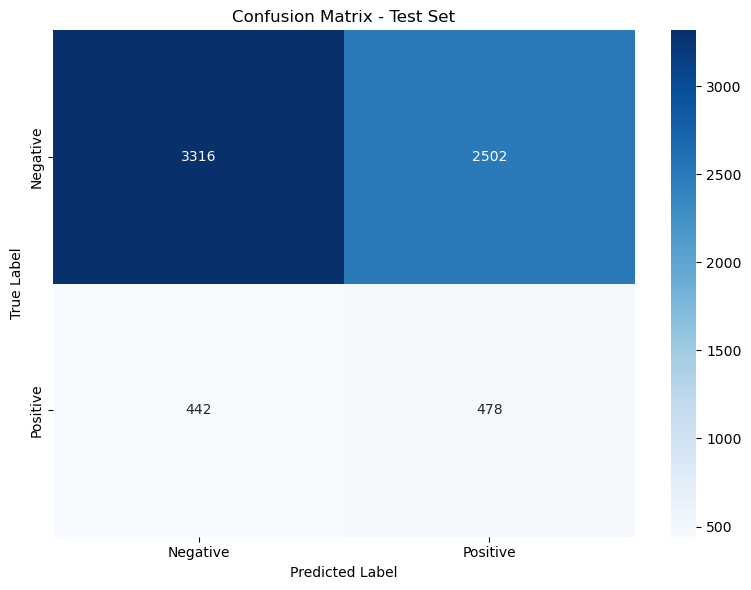

In [50]:
# Compute confusion matrix
cm = confusion_matrix(y_test_array, y_pred_binary)
print("\nConfusion Matrix:")
print(cm)

# Extract TP, TN, FP, FN
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


ROC-AUC Score: 0.5489


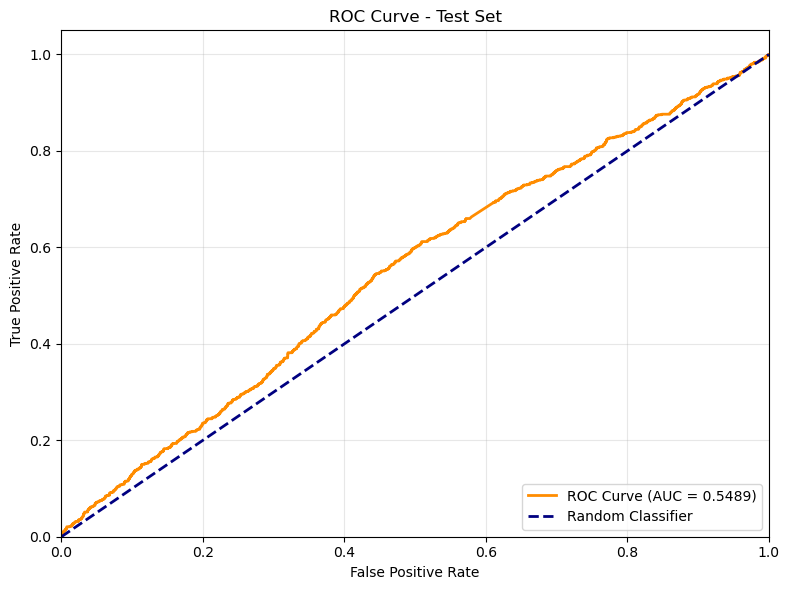

In [51]:
# Compute ROC-AUC
roc_auc = roc_auc_score(y_test_array, y_pred_probs)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Plot ROC curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_array, y_pred_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

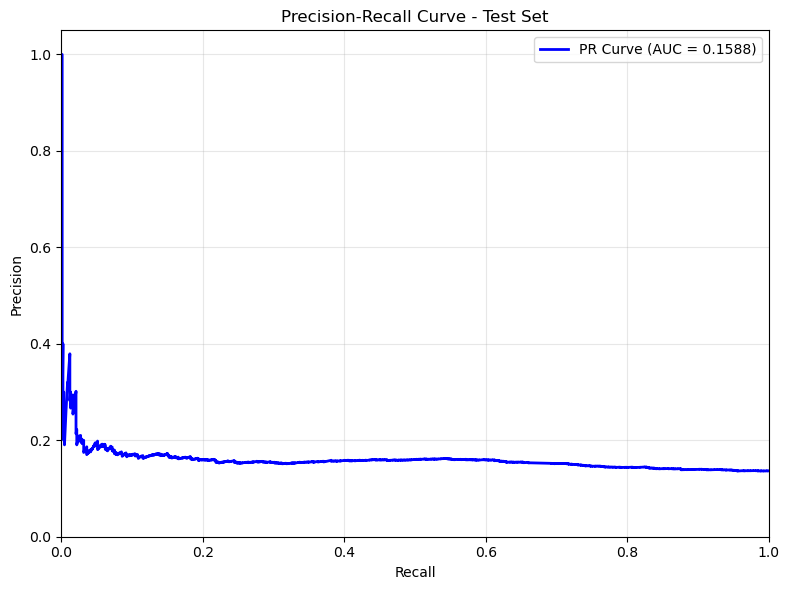


PR-AUC Score: 0.1588


In [52]:
# Compute Precision-Recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_test_array, y_pred_probs)

# Compute area under PR curve
from sklearn.metrics import auc
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Test Set')
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print(f"\nPR-AUC Score: {pr_auc:.4f}")

In [53]:
# Compute additional metrics
recall = recall_score(y_test_array, y_pred_binary)
precision = precision_score(y_test_array, y_pred_binary, zero_division=0)
f1 = f1_score(y_test_array, y_pred_binary, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = recall  # Same as recall

print("\n" + "="*60)
print("CLASSIFICATION METRICS")
print("="*60)
print(f"Recall (True Positive Rate / Sensitivity): {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")
print(f"Accuracy: {(tp + tn) / (tp + tn + fp + fn):.4f}")


CLASSIFICATION METRICS
Recall (True Positive Rate / Sensitivity): 0.5196
Precision: 0.1604
F1-Score: 0.2451
Specificity (True Negative Rate): 0.5700
Accuracy: 0.5631
